# Questão 5 - Runge-Kutta para Sistemas de EDOs de Ordem Superior

Use o Algoritmo de Runge-Kutta para sistemas para encontrar aproximações das soluções dos seguintes sistemas de equações diferenciais de ordem superior e compare os resultados às soluções reais.

## Letra a)

$$t^2y'' - 2ty' + 2y = t^3 \ln t, \quad 1 \leq t \leq 2, \quad y(1) = 1, \quad y'(1) = 0; \quad \text{com } h = 0,1$$

**Solução real:**

$$y(t) = \frac{7}{4}t + \frac{1}{2}t^3 \ln t - \frac{3}{4}t^3$$

## Letra b)

$$y''' + 2y'' - y' - 2y = e^t, \quad 0 \leq t \leq 3, \quad y(0) = 1, \quad y'(0) = 2, \quad y''(0) = 0; \quad \text{com } h = 0,2$$

**Solução real:**

$$y(t) = \frac{43}{36}e^t + \frac{1}{4}e^{-t} - \frac{4}{9}e^{-2t} + \frac{1}{6}te^t$$

QUESTÃO 5 - LETRA A
t		y (aproximado)		y (real)		Erro
1.00		1.0000000000		1.0000000000		0.0000000000
1.10		0.9901781774		0.9901789247		0.0000007473
1.20		0.9615243719		0.9615258251		0.0000014532
1.30		0.9154550179		0.9154571445		0.0000021266
1.40		0.8536371344		0.8536399086		0.0000027742
1.50		0.7779689685		0.7779723699		0.0000034014
1.60		0.6905634205		0.6905674327		0.0000040122
1.70		0.5937336888		0.5937382987		0.0000046099
1.80		0.4899807176		0.4899859149		0.0000051973
1.90		0.3819821262		0.3819879026		0.0000057764
2.00		0.2725823731		0.2725887222		0.0000063491

Erro máximo: 0.0000063491
QUESTÃO 5 - LETRA B
t		y (aproximado)		y (real)		Erro
0.00		1.0000000000		1.0000000000		0.0000000000
0.20		1.4063367806		1.4063738320		0.0000370514
0.40		1.8491814552		1.8492349517		0.0000534965
0.60		2.3619090327		2.3619703731		0.0000613404
0.80		2.9775564328		2.9776242436		0.0000678108
1.00		3.7316269531		3.7317044454		0.0000774923
1.20		4.6646044030		4.6646980604		0.0000936574
1.40		5.8244278262	

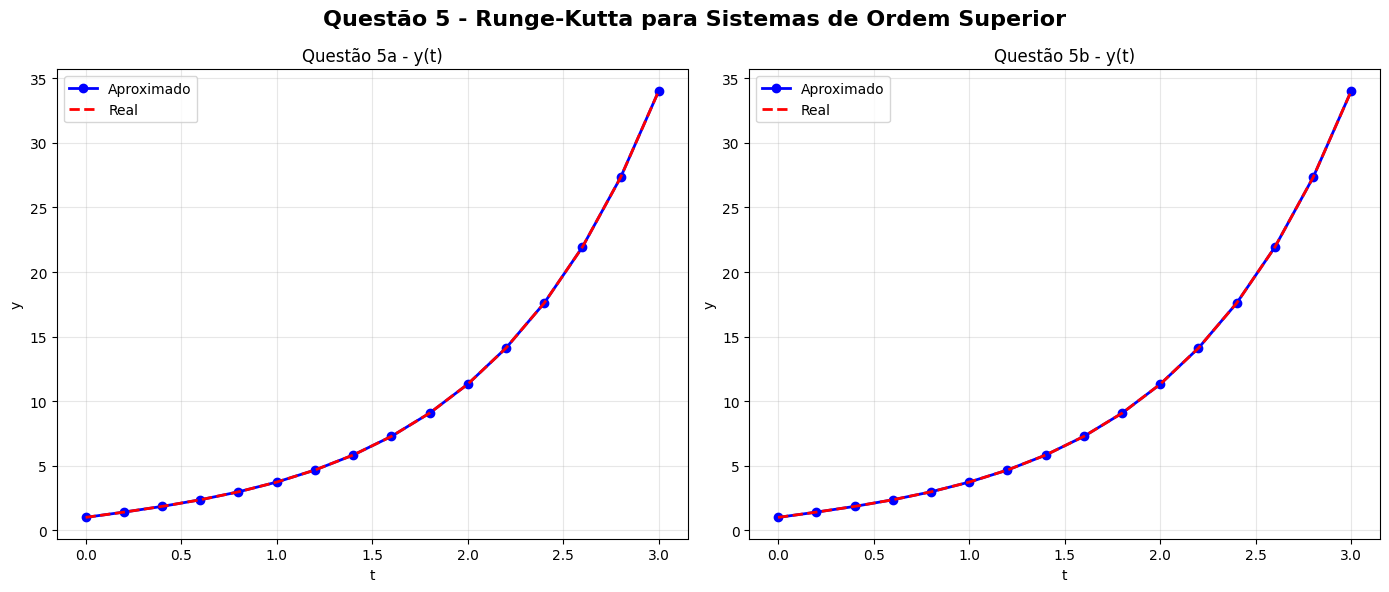

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rk4_system_2d(f1, f2, t0, u1_0, u2_0, h, t_end):
    """Runge-Kutta 4ª ordem para sistemas de 2 EDOs"""
    n = int((t_end - t0) / h)
    t = np.zeros(n+1)
    u1 = np.zeros(n+1)
    u2 = np.zeros(n+1)
    t[0] = t0
    u1[0] = u1_0
    u2[0] = u2_0
    
    for i in range(n):
        t_curr = t[i]
        u1_curr = u1[i]
        u2_curr = u2[i]
        
        k1_1 = f1(t_curr, u1_curr, u2_curr)
        k1_2 = f2(t_curr, u1_curr, u2_curr)
        
        k2_1 = f1(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2)
        k2_2 = f2(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2)
        
        k3_1 = f1(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2)
        k3_2 = f2(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2)
        
        k4_1 = f1(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2)
        k4_2 = f2(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2)
        
        u1[i+1] = u1_curr + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        u2[i+1] = u2_curr + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)
        t[i+1] = t_curr + h
    
    return t, u1, u2


def rk4_system_3d(f1, f2, f3, t0, u1_0, u2_0, u3_0, h, t_end):
    """Runge-Kutta 4ª ordem para sistemas de 3 EDOs"""
    n = int((t_end - t0) / h)
    t = np.zeros(n+1)
    u1 = np.zeros(n+1)
    u2 = np.zeros(n+1)
    u3 = np.zeros(n+1)
    t[0] = t0
    u1[0] = u1_0
    u2[0] = u2_0
    u3[0] = u3_0
    
    for i in range(n):
        t_curr = t[i]
        u1_curr = u1[i]
        u2_curr = u2[i]
        u3_curr = u3[i]
        
        k1_1 = f1(t_curr, u1_curr, u2_curr, u3_curr)
        k1_2 = f2(t_curr, u1_curr, u2_curr, u3_curr)
        k1_3 = f3(t_curr, u1_curr, u2_curr, u3_curr)
        
        k2_1 = f1(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        k2_2 = f2(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        k2_3 = f3(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        
        k3_1 = f1(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        k3_2 = f2(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        k3_3 = f3(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        
        k4_1 = f1(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        k4_2 = f2(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        k4_3 = f3(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        
        u1[i+1] = u1_curr + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        u2[i+1] = u2_curr + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)
        u3[i+1] = u3_curr + (h/6)*(k1_3 + 2*k2_3 + 2*k3_3 + k4_3)
        t[i+1] = t_curr + h
    
    return t, u1, u2, u3

# QUESTÃO 5 - LETRA A
# t^2*y'' - 2t*y' + 2y = t^3*ln(t)
# y(1) = 1, y'(1) = 0
# 
# Transformação: u1 = y, u2 = y'
# u1' = u2
# u2' = (2/t)*u2 - (2/t^2)*u1 + t*ln(t)

def f5a1(t, u1, u2):
    return u2

def f5a2(t, u1, u2):
    return (2/t)*u2 - (2/t**2)*u1 + t*np.log(t)

def sol5a(t):
    return (7/4)*t + (1/2)*t**3*np.log(t) - (3/4)*t**3

print("QUESTÃO 5 - LETRA A")

t0, u1_0, u2_0, h, t_end = 1, 1, 0, 0.1, 2
t, u1, u2 = rk4_system_2d(f5a1, f5a2, t0, u1_0, u2_0, h, t_end)

y_real = sol5a(t)

print("t\t\ty (aproximado)\t\ty (real)\t\tErro")

for i in range(len(t)):
    erro = abs(u1[i] - y_real[i])
    print(f"{t[i]:.2f}\t\t{u1[i]:.10f}\t\t{y_real[i]:.10f}\t\t{erro:.10f}")

erro_max = np.max(np.abs(u1 - y_real))
print(f"\nErro máximo: {erro_max:.10f}")

# QUESTÃO 5 - LETRA B
# y''' + 2y'' - y' - 2y = e^t
# y(0) = 1, y'(0) = 2, y''(0) = 0
# 
# Transformação: u1 = y, u2 = y', u3 = y''
# u1' = u2
# u2' = u3
# u3' = -2u3 + u2 + 2u1 + e^t

def f5b1(t, u1, u2, u3):
    return u2

def f5b2(t, u1, u2, u3):
    return u3

def f5b3(t, u1, u2, u3):
    return -2*u3 + u2 + 2*u1 + np.exp(t)

def sol5b(t):
    return (43/36)*np.exp(t) + (1/4)*np.exp(-t) - (4/9)*np.exp(-2*t) + (1/6)*t*np.exp(t)

print("QUESTÃO 5 - LETRA B")

t0, u1_0, u2_0, u3_0, h, t_end = 0, 1, 2, 0, 0.2, 3
t, u1, u2, u3 = rk4_system_3d(f5b1, f5b2, f5b3, t0, u1_0, u2_0, u3_0, h, t_end)

y_real = sol5b(t)

print("t\t\ty (aproximado)\t\ty (real)\t\tErro")

for i in range(len(t)):
    erro = abs(u1[i] - y_real[i])
    print(f"{t[i]:.2f}\t\t{u1[i]:.10f}\t\t{y_real[i]:.10f}\t\t{erro:.10f}")

erro_max = np.max(np.abs(u1 - y_real))
print(f"\nErro máximo: {erro_max:.10f}")

# GRÁFICOS

plt.figure(figsize=(14, 6))

# Letra A
plt.subplot(1, 2, 1)
plt.plot(t, u1, 'bo-', linewidth=2, markersize=6, label='Aproximado')
plt.plot(t, y_real, 'r--', linewidth=2, label='Real')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Questão 5a - y(t)')
plt.grid(True, alpha=0.3)
plt.legend()

# Letra B
plt.subplot(1, 2, 2)
plt.plot(t, u1, 'bo-', linewidth=2, markersize=6, label='Aproximado')
plt.plot(t, y_real, 'r--', linewidth=2, label='Real')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Questão 5b - y(t)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Questão 5 - Runge-Kutta para Sistemas de Ordem Superior', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()